# E-Commerce Sales Analysis
## Part 2: Data Visualization

**Dataset:** E-Commerce Sales dataset (2,000+ orders, Jan 2024 – Dec 2025)

**Objective:** Turn the raw data into clear, decision-ready charts and dashboards that tell a business story — building on the findings from `Task2_EDA.ipynb`.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/ecommerce_sales.csv", parse_dates=["Order_Date", "Ship_Date"])
df.shape
df = df.drop_duplicates().reset_index(drop=True)
df["Customer_Age"] = df["Customer_Age"].fillna(df["Customer_Age"].median())

## 1. Monthly Sales & Profit Trend

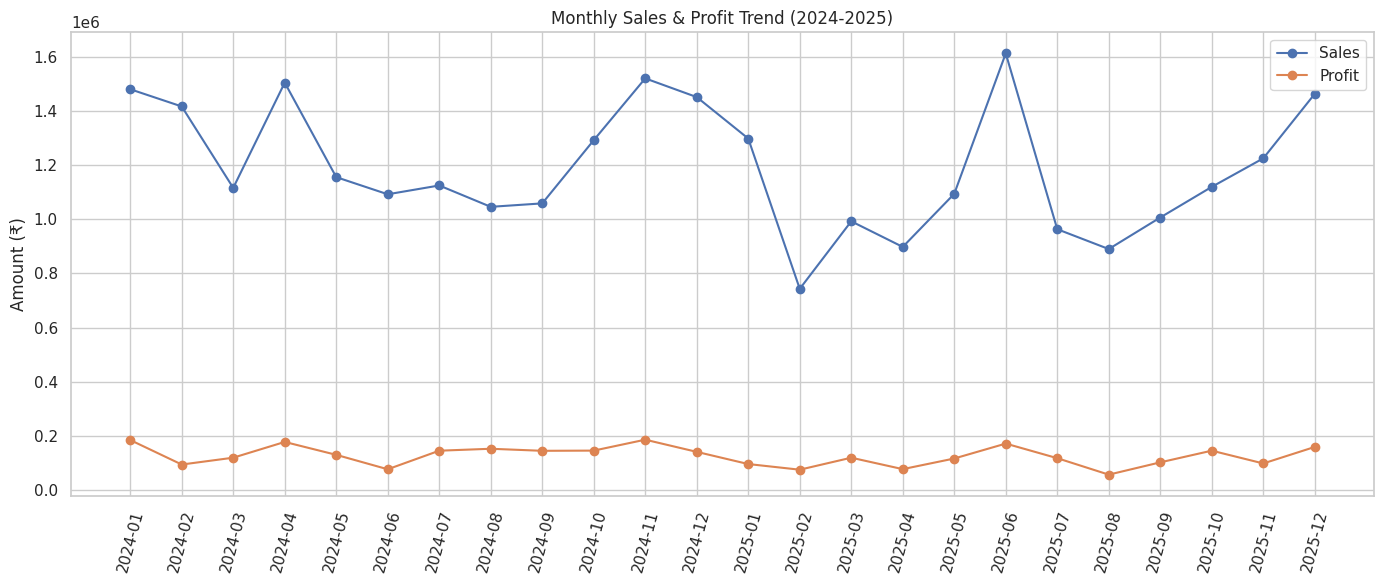

In [2]:
df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Order_Month")[["Sales", "Profit"]].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly["Order_Month"], monthly["Sales"], marker="o", label="Sales", color="#4C72B0")
plt.plot(monthly["Order_Month"], monthly["Profit"], marker="o", label="Profit", color="#DD8452")
plt.xticks(rotation=75)
plt.title("Monthly Sales & Profit Trend (2024-2025)")
plt.ylabel("Amount (₹)")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Category-wise Performance: Sales vs Profit

In [3]:
cat_perf = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
cat_perf["Profit_Margin_%"] = (cat_perf["Profit"] / cat_perf["Sales"] * 100).round(2)
cat_perf

,Sales,Profit,Profit_Margin_%
Category,,,
Electronics,19974969.44,1564779.61,7.83
Home & Kitchen,3854085.41,552824.67,14.34
Sports,1836948.65,288394.68,15.70
Fashion,1700285.50,376339.06,22.13
Beauty,544772.91,150084.01,27.55
Toys,505676.79,102318.47,20.23
Books,145931.90,16917.50,11.59


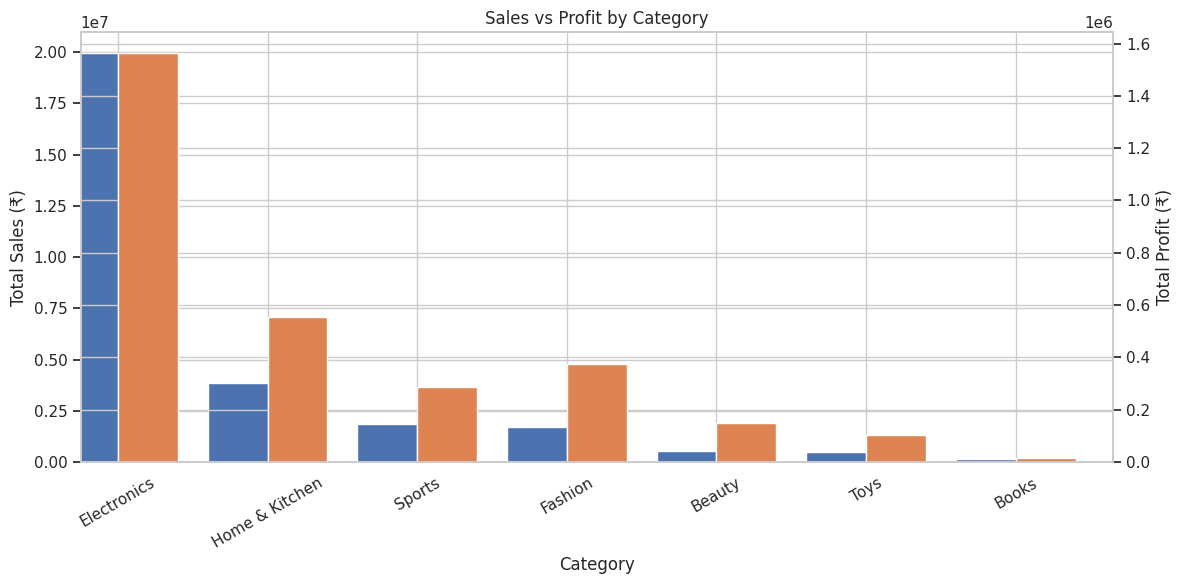

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))
cat_perf["Sales"].plot(kind="bar", color="#4C72B0", ax=ax1, position=1, width=0.4)
ax1.set_ylabel("Total Sales (₹)")

ax2 = ax1.twinx()
cat_perf["Profit"].plot(kind="bar", color="#DD8452", ax=ax2, position=0, width=0.4)
ax2.set_ylabel("Total Profit (₹)")

plt.title("Sales vs Profit by Category")
ax1.set_xticklabels(cat_perf.index, rotation=30)
fig.tight_layout()
plt.show()

## 3. Regional & Customer Segment Breakdown

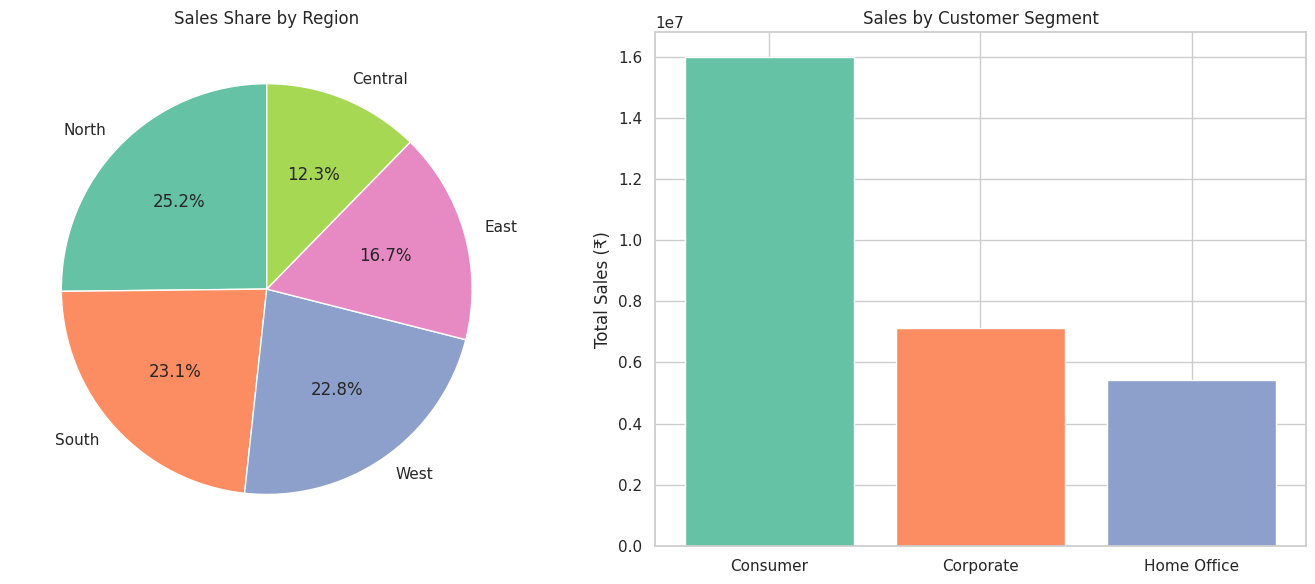

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
axes[0].pie(region_sales, labels=region_sales.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title("Sales Share by Region")

segment_sales = df.groupby("Customer_Segment")["Sales"].sum().sort_values(ascending=False)
axes[1].bar(segment_sales.index, segment_sales.values, color=sns.color_palette("Set2"))
axes[1].set_title("Sales by Customer Segment")
axes[1].set_ylabel("Total Sales (₹)")

plt.tight_layout()
plt.show()

## 4. Discount Impact on Profit
Visualizing what the EDA statistics showed.

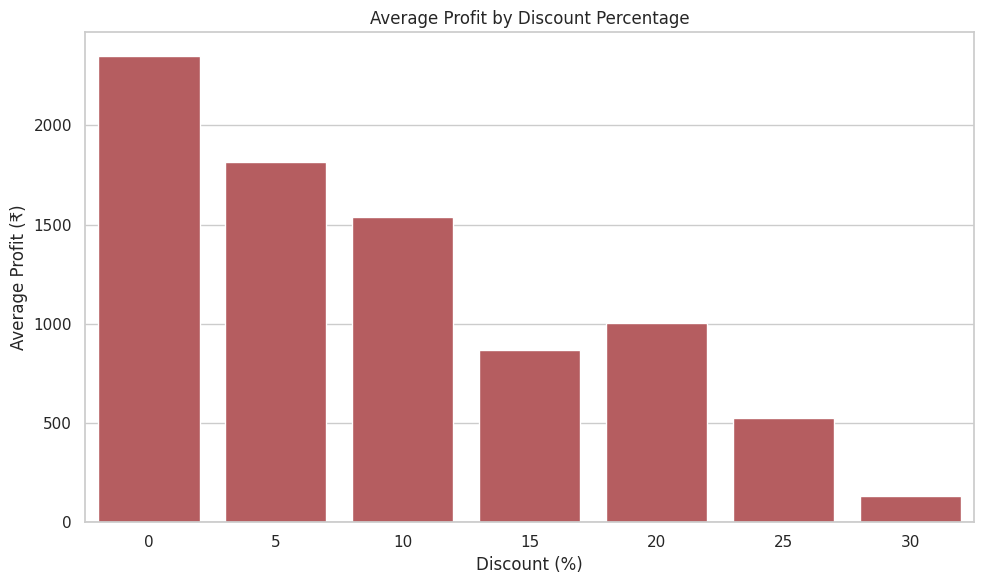

In [6]:
discount_profit = df.groupby("Discount_Percent")["Profit"].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=discount_profit.index, y=discount_profit.values, color="#C44E52")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Profit by Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit (₹)")
plt.tight_layout()
plt.show()

## 5. Payment Mode & Shipping Preferences

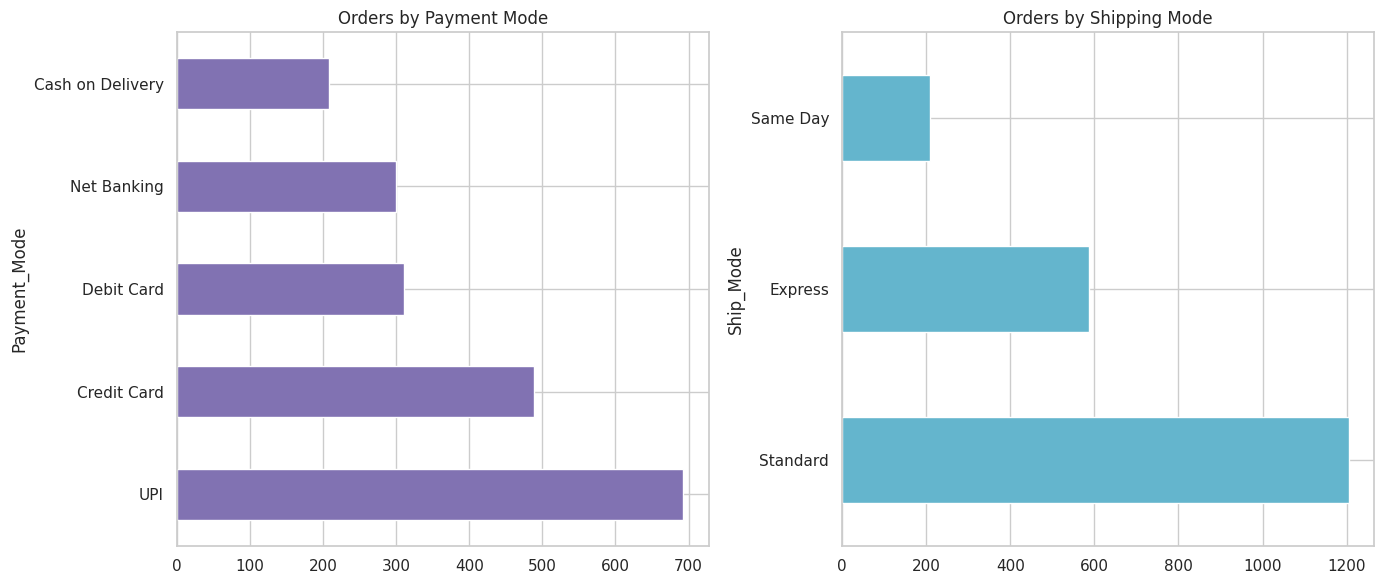

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df["Payment_Mode"].value_counts().plot(kind="barh", ax=axes[0], color="#8172B2")
axes[0].set_title("Orders by Payment Mode")

df["Ship_Mode"].value_counts().plot(kind="barh", ax=axes[1], color="#64B5CD")
axes[1].set_title("Orders by Shipping Mode")

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

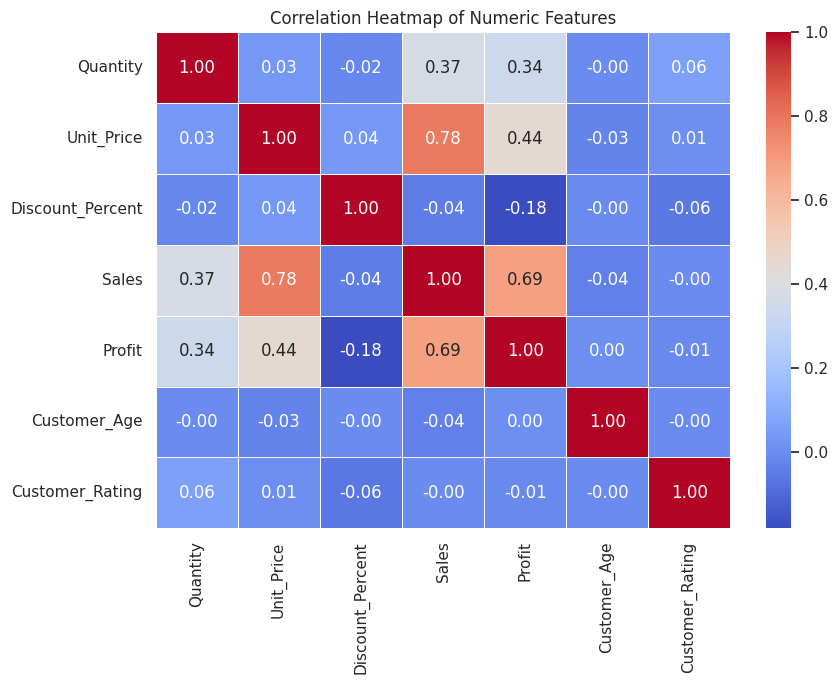

In [8]:
numeric_cols = ["Quantity", "Unit_Price", "Discount_Percent", "Sales", "Profit", "Customer_Age", "Customer_Rating"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## 7. Profit Distribution & Outliers by Category

/tmp/ipykernel_552/912675196.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit", palette="Set3")


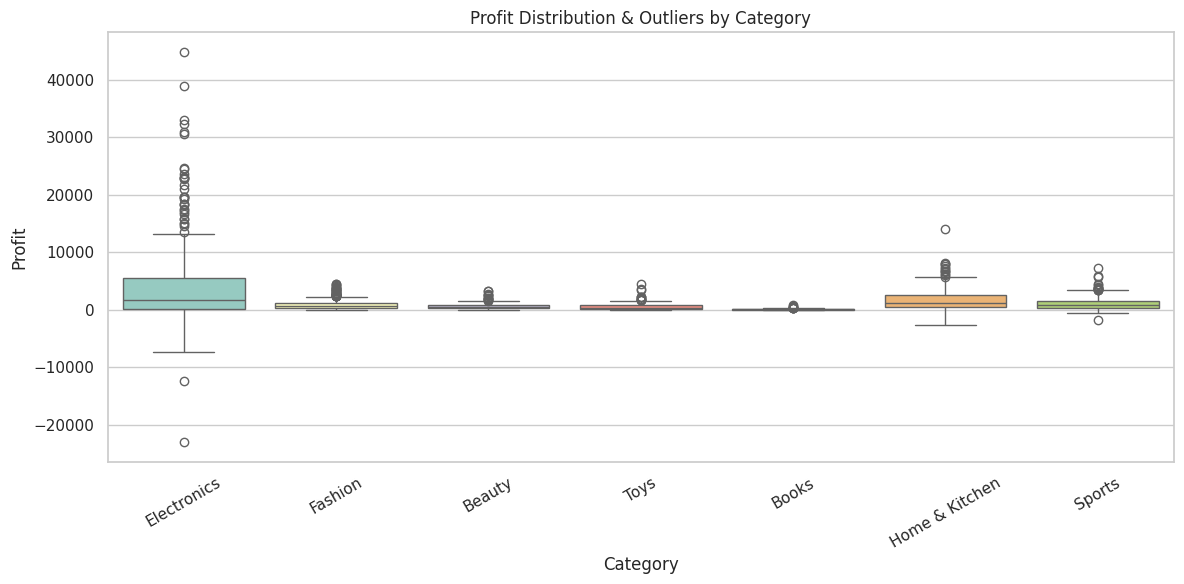

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Category", y="Profit", palette="Set3")
plt.title("Profit Distribution & Outliers by Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Visualization Summary — The Business Story

- **Electronics** drives the highest total sales but has the **thinnest profit margin**; **Beauty** and **Fashion** are lower volume but far more profitable per rupee of sales.
- **Discounting hurts profit**: average profit per order trends downward as discount % rises, with 25–30% discounts pushing several orders into a loss.
- **Seasonality is real**: monthly sales/profit show clear peaks and dips rather than flat growth — useful for planning inventory and campaigns.
- **West and North regions** contribute the largest share of sales, useful for prioritizing regional marketing spend.
- **UPI and Credit Card** dominate payment preference; most customers pick **Standard shipping** over Express/Same Day.

### Next Steps
These visuals could be turned into a live, interactive **Power BI dashboard** (KPI cards + slicers for Category/Region/Segment) for stakeholders.
